In [1]:
#Import Libraries
import pandas as pd
import numpy as np

In [3]:
#Load Dataset
df=pd.read_csv('/content/employee_salary_dataset.csv')
print(df.head())

   EmployeeID        Name  Department  Experience_Years Education_Level  Age  \
0           1  Employee_1   Marketing                15          Master   53   
1           2  Employee_2  Operations                 7        Bachelor   25   
2           3  Employee_3          IT                12     High School   51   
3           4  Employee_4  Operations                 8             PhD   44   
4           5  Employee_5  Operations                15          Master   36   

   Gender       City  Monthly_Salary  
0  Female      Delhi          111416  
1  Female  Bangalore           95271  
2  Female  Hyderabad           69064  
3    Male      Delhi           95091  
4  Female      Delhi          132450  


In [4]:
## Displays concise summary of the DataFrame including:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   EmployeeID        50 non-null     int64 
 1   Name              50 non-null     object
 2   Department        50 non-null     object
 3   Experience_Years  50 non-null     int64 
 4   Education_Level   50 non-null     object
 5   Age               50 non-null     int64 
 6   Gender            50 non-null     object
 7   City              50 non-null     object
 8   Monthly_Salary    50 non-null     int64 
dtypes: int64(4), object(5)
memory usage: 3.6+ KB


In [5]:
# Checks total number of missing (null) values in each column of the DataFrame
df.isnull().sum()

,0
EmployeeID,0
Name,0
Department,0
Experience_Years,0
Education_Level,0
Age,0
Gender,0
City,0
Monthly_Salary,0


In [6]:
# Calculate group-wise mean and standard deviation
mean_by_department = df.groupby('Department')['Monthly_Salary'].transform('mean')
std_by_department = df.groupby('Department')['Monthly_Salary'].transform('std')


In [7]:
# Calculate Z_Score, handling cases where standard deviation is zero
df['Z_Score'] = np.where(std_by_department == 0, 0, (df['Monthly_Salary'] - mean_by_department) / std_by_department)

In [8]:
# Display the head of the DataFrame with the new Z_Score column
print(df.head())

   EmployeeID        Name  Department  Experience_Years Education_Level  Age  \
0           1  Employee_1   Marketing                15          Master   53   
1           2  Employee_2  Operations                 7        Bachelor   25   
2           3  Employee_3          IT                12     High School   51   
3           4  Employee_4  Operations                 8             PhD   44   
4           5  Employee_5  Operations                15          Master   36   

   Gender       City  Monthly_Salary   Z_Score  
0  Female      Delhi          111416  0.485238  
1  Female  Bangalore           95271  0.289184  
2  Female  Hyderabad           69064 -0.223046  
3    Male      Delhi           95091  0.284465  
4  Female      Delhi          132450  1.263844  


In [9]:
## After Standardization(Z_Score)
df.groupby('Department')['Z_Score'].agg(['mean','std'])

,mean,std
Department,,
Finance,2.220446e-16,1.0
HR,5.947623e-17,1.0
IT,1.110223e-17,1.0
Marketing,-5.978124e-17,1.0
Operations,1.554312e-16,1.0


In [10]:
# Sets the limit (threshold) to identify outliers using Z-score
threshold = 2

In [11]:
# Creates a new column 'Outlier' to label records as 'Yes' if Z_Score exceeds the threshold, otherwise 'No'
df['Outlier'] = df['Z_Score'].apply(
    lambda x: 'Yes' if abs(x) > threshold else 'No'
)

In [12]:
# Displays the complete DataFrame with all columns and rows with zscore and outlier
print(df.head(25))

    EmployeeID         Name  Department  Experience_Years Education_Level  \
0            1   Employee_1   Marketing                15          Master   
1            2   Employee_2  Operations                 7        Bachelor   
2            3   Employee_3          IT                12     High School   
3            4   Employee_4  Operations                 8             PhD   
4            5   Employee_5  Operations                15          Master   
5            6   Employee_6     Finance                 3     High School   
6            7   Employee_7          IT                14             PhD   
7            8   Employee_8          IT                17             PhD   
8            9   Employee_9          IT                 4        Bachelor   
9           10  Employee_10  Operations                18     High School   
10          11  Employee_11   Marketing                 8             PhD   
11          12  Employee_12          IT                 4          Master   

In [13]:
#Display only detected outlier records
outliers = df[df['Outlier'] == 'Yes']
print("Outliers:\n", outliers)

Outliers:
     EmployeeID         Name Department  Experience_Years Education_Level  Age  \
16          17  Employee_17  Marketing                18          Master   41   

    Gender       City  Monthly_Salary   Z_Score Outlier  
16  Female  Hyderabad           30895 -2.122133     Yes  


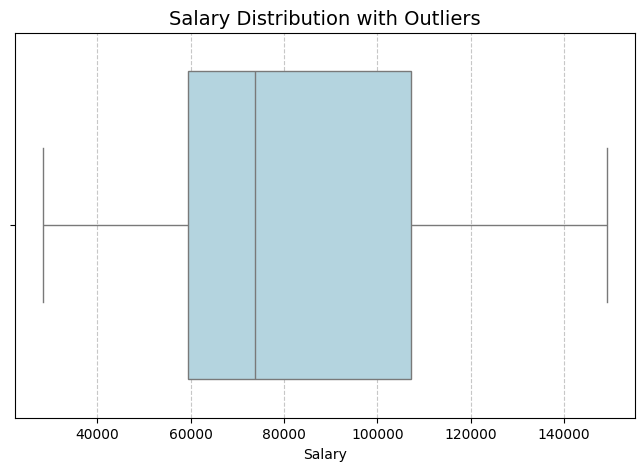

In [16]:
import seaborn as sns
import  matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(x=df['Monthly_Salary'],color='lightblue')
plt.title('Salary Distribution with Outliers',fontsize=14)
plt.xlabel('Salary')
plt.grid(axis='x',linestyle='--',alpha=0.7)
plt.show()